# Major Project Notebook (DL): Calibrated Gated Ensemble

This notebook is **Deep Learning (DL)** focused (not ML) and compares against the existing DL baseline.

## Problem We Actually Solve
The baseline AE detector is strong, but a single detector has blind spots under NSL-KDD train-test shift:
- reconstruction catches some attack families very well
- latent classifier catches different families
- relying on only one score leaves recall gaps on specific attack types

## Proposed Method
Calibrated Two-Stage Gated Ensemble:
1. Stage-1: Autoencoder reconstruction detector
2. Stage-2: Latent classifier detector with threshold calibrated on a leakage-safe normal calibration split
3. Final decision: anomaly if either stage fires (gated OR)

This notebook enforces calibration hygiene (no threshold calibration on samples used to train the latent classifier).


In [1]:
import json
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    f1_score,
)

from keras import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.models import load_model
from keras.optimizers import Adam

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = ROOT / "data"
BASELINE_ARTIFACT_DIR = ROOT / "checkpoints" / "autoencoder_major"
PROJECT_ARTIFACT_DIR = ROOT / "checkpoints" / "autoencoder_major_project_gated"
PLOT_DIR = ROOT / "extra" / "notebook_plots"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("BASELINE_ARTIFACT_DIR:", BASELINE_ARTIFACT_DIR)
print("PROJECT_ARTIFACT_DIR:", PROJECT_ARTIFACT_DIR)

ROOT: C:\Users\shain\Downloads\Network-Anomaly-Detection
DATA_DIR: C:\Users\shain\Downloads\Network-Anomaly-Detection\data
BASELINE_ARTIFACT_DIR: C:\Users\shain\Downloads\Network-Anomaly-Detection\checkpoints\autoencoder_major
PROJECT_ARTIFACT_DIR: C:\Users\shain\Downloads\Network-Anomaly-Detection\checkpoints\autoencoder_major_project_gated


In [2]:
NSL_KDD_COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment",
    "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

urls = {
    "train": "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt",
    "test": "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt",
}

train_path = DATA_DIR / "KDDTrain+.txt"
test_path = DATA_DIR / "KDDTest+.txt"

if not train_path.exists():
    urlretrieve(urls["train"], train_path.as_posix())
if not test_path.exists():
    urlretrieve(urls["test"], test_path.as_posix())

train_df = pd.read_csv(train_path, names=NSL_KDD_COLUMNS)
test_df = pd.read_csv(test_path, names=NSL_KDD_COLUMNS)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head(3))

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


In [3]:
# Problem quantification: distribution shift and unseen attack types
y_train_bin = (train_df["label"].astype(str) != "normal").astype(int)
y_test_bin = (test_df["label"].astype(str) != "normal").astype(int)

train_attack_types = set(train_df.loc[train_df["label"] != "normal", "label"].astype(str).unique())
test_attack_types = set(test_df.loc[test_df["label"] != "normal", "label"].astype(str).unique())
unseen_test_attacks = sorted(list(test_attack_types - train_attack_types))

shift_df = pd.DataFrame([
    {
        "split": "train",
        "rows": int(len(train_df)),
        "anomaly_ratio": float(y_train_bin.mean()),
        "attack_types": int(len(train_attack_types)),
    },
    {
        "split": "test",
        "rows": int(len(test_df)),
        "anomaly_ratio": float(y_test_bin.mean()),
        "attack_types": int(len(test_attack_types)),
    },
])

display(shift_df)
print("Unseen test attack types count:", len(unseen_test_attacks))
print("Some unseen attack types:", unseen_test_attacks[:15])

,split,rows,anomaly_ratio,attack_types
0,train,125973,0.465417,22
1,test,22544,0.569242,37


Unseen test attack types count: 17
Some unseen attack types: ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock']


In [ ]:
def fit_preprocessor(X_train_df: pd.DataFrame):
    X_train_df = X_train_df.copy()
    cat_cols = X_train_df.select_dtypes(include=["object"]).columns.tolist()
    num_cols = [c for c in X_train_df.columns if c not in cat_cols]

    for c in cat_cols:
        X_train_df[c] = X_train_df[c].fillna("Unknown").astype(str)
    for c in num_cols:
        med = X_train_df[c].median()
        X_train_df[c] = X_train_df[c].fillna(med)

    ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    if cat_cols:
        X_train_df[cat_cols] = ordinal.fit_transform(X_train_df[cat_cols])

    scaler = StandardScaler()
    scaler.fit(X_train_df.values)

    return ordinal, scaler, X_train_df.columns.tolist(), cat_cols


def transform_with_preprocessor(X_df, ordinal, scaler, feature_names, cat_cols):
    X_df = X_df.copy()
    for c in feature_names:
        if c not in X_df.columns:
            X_df[c] = 0
    X_df = X_df[feature_names]

    num_cols = [c for c in feature_names if c not in cat_cols]
    for c in cat_cols:
        X_df[c] = X_df[c].fillna("Unknown").astype(str)
    for c in num_cols:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce")
        med = X_df[c].median()
        if pd.isna(med):
            med = 0.0
        X_df[c] = X_df[c].fillna(med)

    if cat_cols:
        X_df[cat_cols] = ordinal.transform(X_df[cat_cols])

    return scaler.transform(X_df.values)


y_train = (train_df["label"].astype(str) != "normal").astype(int).values
y_test = (test_df["label"].astype(str) != "normal").astype(int).values

X_train_raw = train_df.drop(columns=["label", "difficulty"], errors="ignore").copy()
X_test_raw = test_df.drop(columns=["label", "difficulty"], errors="ignore").copy()

ordinal_encoder, scaler, feature_names, cat_cols = fit_preprocessor(X_train_raw)
X_train = transform_with_preprocessor(X_train_raw, ordinal_encoder, scaler, feature_names, cat_cols)
X_test = transform_with_preprocessor(X_test_raw, ordinal_encoder, scaler, feature_names, cat_cols)

# AE split: train and calibrate reconstruction threshold on normal-only traffic
X_train_normal = X_train[y_train == 0]
x_norm_train, x_norm_val = train_test_split(X_train_normal, test_size=0.2, random_state=SEED)

# Leakage-safe split for latent model and latent-threshold calibration
X_lat_train, X_lat_cal, y_lat_train, y_lat_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED + 7,
    stratify=y_train,
)
X_lat_cal_normal = X_lat_cal[y_lat_cal == 0]

if X_lat_cal_normal.shape[0] == 0:
    raise ValueError("Latent calibration normal split is empty. Adjust split strategy.")

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Normal train split:", x_norm_train.shape, "Normal val split:", x_norm_val.shape)
print("Latent train split:", X_lat_train.shape, "Latent calibration split:", X_lat_cal.shape)
print("Latent calibration normal rows:", X_lat_cal_normal.shape[0])


In [ ]:
def build_autoencoder(input_dim: int, latent_dim: int = 32):
    inp = Input(shape=(input_dim,), name="ae_input")
    x = Dense(128, activation="relu")(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation="relu")(x)
    latent = Dense(latent_dim, activation="relu", name="latent")(x)
    x = Dense(64, activation="relu")(latent)
    x = Dropout(0.1)(x)
    x = Dense(128, activation="relu")(x)
    out = Dense(input_dim, activation="linear", name="ae_output")(x)

    autoencoder = Model(inp, out, name="major_project_autoencoder")
    autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
    return autoencoder


TRAIN_FROM_SCRATCH = True
baseline_ae_path = BASELINE_ARTIFACT_DIR / "autoencoder_major.keras"
project_ae_path = PROJECT_ARTIFACT_DIR / "autoencoder_major_project.keras"

if (not TRAIN_FROM_SCRATCH) and baseline_ae_path.exists():
    autoencoder = load_model(baseline_ae_path)
    print("Loaded baseline autoencoder from:", baseline_ae_path)
else:
    autoencoder = build_autoencoder(X_train.shape[1], latent_dim=32)
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    ]
    history = autoencoder.fit(
        x_norm_train,
        x_norm_train,
        validation_data=(x_norm_val, x_norm_val),
        epochs=30,
        batch_size=512,
        shuffle=True,
        callbacks=callbacks,
        verbose=1,
    )
    autoencoder.save(project_ae_path.as_posix())
    print("Trained and saved autoencoder to:", project_ae_path)

encoder = Model(autoencoder.input, autoencoder.get_layer("latent").output)
latent_train = encoder.predict(X_lat_train, verbose=0)
latent_cal = encoder.predict(X_lat_cal, verbose=0)
latent_test = encoder.predict(X_test, verbose=0)

latent_clf = LogisticRegression(max_iter=3000, random_state=SEED)
latent_clf.fit(latent_train, y_lat_train)

latent_prob = latent_clf.predict_proba(latent_test)[:, 1]
latent_prob_cal = latent_clf.predict_proba(latent_cal)[:, 1]
latent_prob_cal_normal = latent_prob_cal[y_lat_cal == 0]
latent_pred = (latent_prob >= 0.5).astype(int)

print("Latent classifier trained on leakage-safe split.")
print("Latent calibration normal rows:", latent_prob_cal_normal.shape[0])


In [ ]:
# Baseline evaluation (existing-style)
val_recon = autoencoder.predict(x_norm_val, verbose=0)
val_err = np.mean(np.square(x_norm_val - val_recon), axis=1)
recon_threshold = float(np.quantile(val_err, 0.95))

# Calibration reconstruction errors (for leakage-safe ablation)
cal_recon = autoencoder.predict(X_lat_cal, verbose=0)
cal_err = np.mean(np.square(X_lat_cal - cal_recon), axis=1)
ae_pred_cal = (cal_err >= recon_threshold).astype(int)

test_recon = autoencoder.predict(X_test, verbose=0)
test_err = np.mean(np.square(X_test - test_recon), axis=1)
ae_pred = (test_err >= recon_threshold).astype(int)


def summarize_detector(name, y_true, y_pred, score):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {
        "detector": name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "roc_auc": float(roc_auc_score(y_true, score)),
        "pr_auc": float(average_precision_score(y_true, score)),
    }

baseline_ae = summarize_detector("AE Reconstruction", y_test, ae_pred, test_err)
baseline_latent = summarize_detector("Latent LR", y_test, latent_pred, latent_prob)
baseline_df = pd.DataFrame([baseline_ae, baseline_latent])
display(baseline_df)
print("Reconstruction threshold:", round(recon_threshold, 6))


## New Method: Calibrated Two-Stage Gated Ensemble

Decision rule:

$$\hat{y}(x)=\mathbf{1}[e(x)\ge \tau_e \;\;\text{or}\;\; p_{latent}(x)\ge \tau_l]$$

where:
- $e(x)$ is reconstruction error
- $\tau_e$ is reconstruction threshold from normal validation
- $p_{latent}(x)$ is latent classifier probability
- $\tau_l$ is latent threshold calibrated from normal validation

In [ ]:
latent_threshold = float(np.quantile(latent_prob_cal_normal, 0.95))
pred_gated_or = np.where((ae_pred == 1) | (latent_prob >= latent_threshold), 1, 0)

# Combined score for ranking and ROC/PR
score_recon_norm_cal = cal_err / (recon_threshold + 1e-12)
score_recon_norm_test = test_err / (recon_threshold + 1e-12)
score_lat_norm_cal = latent_prob_cal / (latent_threshold + 1e-12)
score_lat_norm_test = latent_prob / (latent_threshold + 1e-12)

score_gated = np.maximum(score_recon_norm_test, score_lat_norm_test)

# Normal-only calibration scores for conformal decision
cal_err_normal = cal_err[y_lat_cal == 0]
score_recon_norm_cal_normal = cal_err_normal / (recon_threshold + 1e-12)
score_lat_norm_cal_normal = latent_prob_cal_normal / (latent_threshold + 1e-12)
cal_score_gated_normal = np.maximum(score_recon_norm_cal_normal, score_lat_norm_cal_normal)

# Optional conformal decision (alpha=0.05)
alpha = 0.05
p_values = np.array([
    (np.sum(cal_score_gated_normal >= s) + 1) / (len(cal_score_gated_normal) + 1)
    for s in score_gated
])
pred_gated_conformal = (p_values < alpha).astype(int)

gated_or_summary = summarize_detector("Gated OR", y_test, pred_gated_or, score_gated)
gated_conf_summary = summarize_detector("Gated Conformal (alpha=0.05)", y_test, pred_gated_conformal, score_gated)

major_table = pd.DataFrame([baseline_ae, baseline_latent, gated_or_summary, gated_conf_summary])
display(major_table)
print("Latent threshold (95th percentile on leakage-safe normal calibration):", round(latent_threshold, 6))


In [ ]:
# Ablation study: calibration-driven threshold analysis (no test-set tuning)
rows = []
for q in np.linspace(0.90, 0.99, 10):
    lat_q = float(np.quantile(latent_prob_cal_normal, q))

    # Calibration split metrics (used for threshold-selection diagnostics)
    pred_or_cal = np.where((ae_pred_cal == 1) | (latent_prob_cal >= lat_q), 1, 0)
    pred_and_cal = np.where((ae_pred_cal == 1) & (latent_prob_cal >= lat_q), 1, 0)

    score_or_cal = np.maximum(cal_err / (recon_threshold + 1e-12), latent_prob_cal / (lat_q + 1e-12))
    score_and_cal = np.minimum(cal_err / (recon_threshold + 1e-12), latent_prob_cal / (lat_q + 1e-12))

    s_or_cal = summarize_detector("OR_cal", y_lat_cal, pred_or_cal, score_or_cal)
    s_and_cal = summarize_detector("AND_cal", y_lat_cal, pred_and_cal, score_and_cal)

    # Test split metrics (held-out reporting only)
    pred_or_test = np.where((ae_pred == 1) | (latent_prob >= lat_q), 1, 0)
    pred_and_test = np.where((ae_pred == 1) & (latent_prob >= lat_q), 1, 0)

    score_or_test = np.maximum(test_err / (recon_threshold + 1e-12), latent_prob / (lat_q + 1e-12))
    score_and_test = np.minimum(test_err / (recon_threshold + 1e-12), latent_prob / (lat_q + 1e-12))

    s_or_test = summarize_detector("OR_test", y_test, pred_or_test, score_or_test)
    s_and_test = summarize_detector("AND_test", y_test, pred_and_test, score_and_test)

    rows.append(
        {
            "rule": "OR",
            "q": q,
            "f1_cal": s_or_cal["f1"],
            "f1_test": s_or_test["f1"],
            "precision_test": s_or_test["precision"],
            "recall_test": s_or_test["recall"],
        }
    )
    rows.append(
        {
            "rule": "AND",
            "q": q,
            "f1_cal": s_and_cal["f1"],
            "f1_test": s_and_test["f1"],
            "precision_test": s_and_test["precision"],
            "recall_test": s_and_test["recall"],
        }
    )

ablation_df = pd.DataFrame(rows).sort_values(["rule", "f1_cal"], ascending=[True, False])
display(ablation_df.head(12))

best_or_calibration = (
    ablation_df[ablation_df["rule"] == "OR"]
    .sort_values(["f1_cal", "q"], ascending=[False, True])
    .iloc[0]
    .to_dict()
)
print("Calibration-selected OR quantile:", round(float(best_or_calibration["q"]), 4))
print("Calibration-selected OR -> test F1:", round(float(best_or_calibration["f1_test"]), 4))

plt.figure(figsize=(10, 4))
for rule_name in ["OR", "AND"]:
    tmp = ablation_df[ablation_df["rule"] == rule_name].sort_values("q")
    plt.plot(tmp["q"], tmp["f1_cal"], marker="o", label=f"{rule_name} (calibration F1)")
    plt.plot(tmp["q"], tmp["f1_test"], marker="x", linestyle="--", label=f"{rule_name} (test F1)")

plt.title("Ablation: F1 vs latent quantile (calibration-driven)")
plt.xlabel("latent threshold quantile")
plt.ylabel("F1")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Seen vs unseen attack recall (major-project quality analysis)
train_attack_set = set(train_df.loc[train_df["label"] != "normal", "label"].astype(str).unique())
test_labels = test_df["label"].astype(str).values

seen_mask = np.array([(lbl != "normal") and (lbl in train_attack_set) for lbl in test_labels])
unseen_mask = np.array([(lbl != "normal") and (lbl not in train_attack_set) for lbl in test_labels])


def masked_recall(y_pred, mask):
    n = int(mask.sum())
    if n == 0:
        return np.nan
    return float((y_pred[mask] == 1).sum() / n)

seen_unseen_df = pd.DataFrame([
    {
        "detector": "AE Reconstruction",
        "seen_attack_recall": masked_recall(ae_pred, seen_mask),
        "unseen_attack_recall": masked_recall(ae_pred, unseen_mask),
    },
    {
        "detector": "Latent LR",
        "seen_attack_recall": masked_recall(latent_pred, seen_mask),
        "unseen_attack_recall": masked_recall(latent_pred, unseen_mask),
    },
    {
        "detector": "Gated OR",
        "seen_attack_recall": masked_recall(pred_gated_or, seen_mask),
        "unseen_attack_recall": masked_recall(pred_gated_or, unseen_mask),
    },
])

display(seen_unseen_df)
print("Seen attack rows:", int(seen_mask.sum()), "| Unseen attack rows:", int(unseen_mask.sum()))

,detector,seen_attack_recall,unseen_attack_recall
0,AE Reconstruction,0.815810,0.804533
1,Latent LR,0.736651,0.569867
2,Gated OR,0.862711,0.806400


Seen attack rows: 9083 | Unseen attack rows: 3750


,attack_type,count,ae_recall,gated_recall
0,neptune,4657,0.999785,0.999785
1,guess_passwd,1231,0.392364,0.393176
2,mscan,996,0.988956,0.991968
3,warezmaster,944,0.538136,0.883475
4,apache2,737,0.997286,0.997286
5,satan,735,0.770068,0.893878
6,processtable,685,1.000000,1.000000
7,smurf,665,0.993985,1.000000
8,back,359,0.208914,0.208914
9,snmpguess,331,0.012085,0.012085


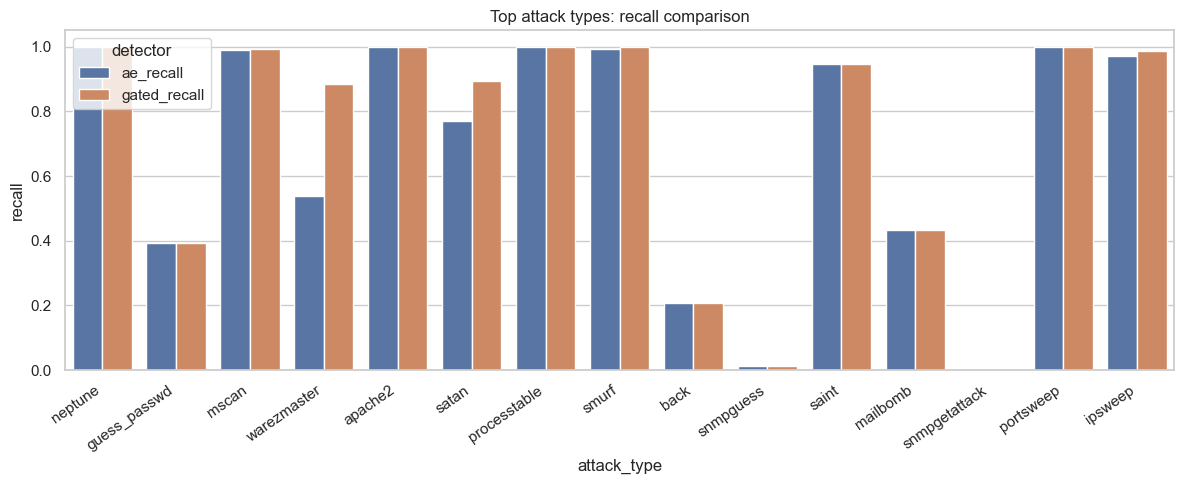

In [10]:
# Attack-type-wise recall comparison
attack_df = pd.DataFrame({
    "attack_type": test_df["label"].astype(str),
    "is_attack": y_test,
    "ae_pred": ae_pred,
    "gated_pred": pred_gated_or,
})

attack_only = attack_df[attack_df["is_attack"] == 1].copy()
attack_recall = attack_only.groupby("attack_type").agg(
    count=("attack_type", "size"),
    ae_recall=("ae_pred", "mean"),
    gated_recall=("gated_pred", "mean"),
).sort_values("count", ascending=False).head(15).reset_index()

display(attack_recall)

plot_attack = attack_recall.melt(
    id_vars=["attack_type", "count"],
    value_vars=["ae_recall", "gated_recall"],
    var_name="detector",
    value_name="recall",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_attack, x="attack_type", y="recall", hue="detector")
plt.title("Top attack types: recall comparison")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

F1 delta (gated - AE) mean: 0.01193
95% bootstrap CI: [0.00995, 0.01408]
P(F1 improvement > 0): 1.0000


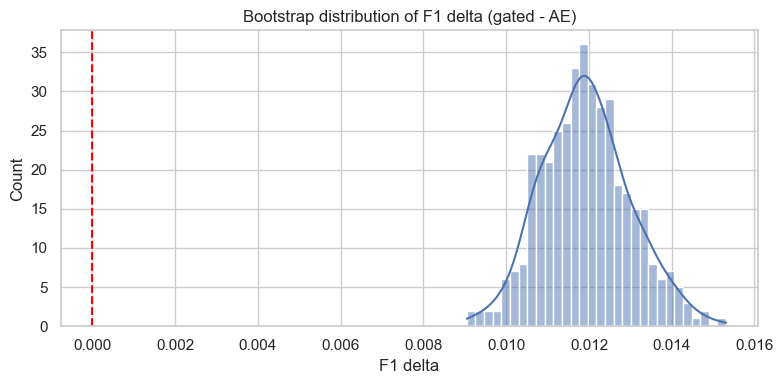

In [11]:
# Statistical validation: bootstrap CI for F1 improvement
rng = np.random.default_rng(SEED)
indices = np.arange(len(y_test))
n_boot = 400
f1_diffs = []

for _ in range(n_boot):
    b_idx = rng.choice(indices, size=len(indices), replace=True)
    f1_ae = f1_score(y_test[b_idx], ae_pred[b_idx], zero_division=0)
    f1_gated = f1_score(y_test[b_idx], pred_gated_or[b_idx], zero_division=0)
    f1_diffs.append(f1_gated - f1_ae)

f1_diffs = np.array(f1_diffs)
ci_low, ci_high = np.percentile(f1_diffs, [2.5, 97.5])
mean_diff = float(np.mean(f1_diffs))
prob_improve = float(np.mean(f1_diffs > 0))

print(f"F1 delta (gated - AE) mean: {mean_diff:.5f}")
print(f"95% bootstrap CI: [{ci_low:.5f}, {ci_high:.5f}]")
print(f"P(F1 improvement > 0): {prob_improve:.4f}")

plt.figure(figsize=(8, 4))
sns.histplot(f1_diffs, bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Bootstrap distribution of F1 delta (gated - AE)")
plt.xlabel("F1 delta")
plt.tight_layout()
plt.show()

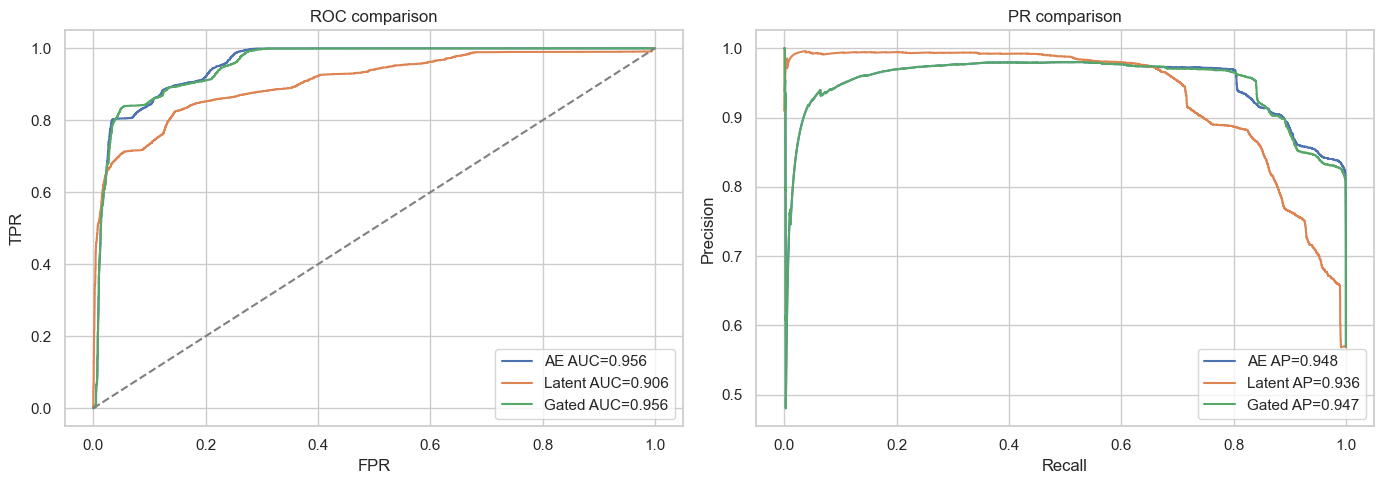

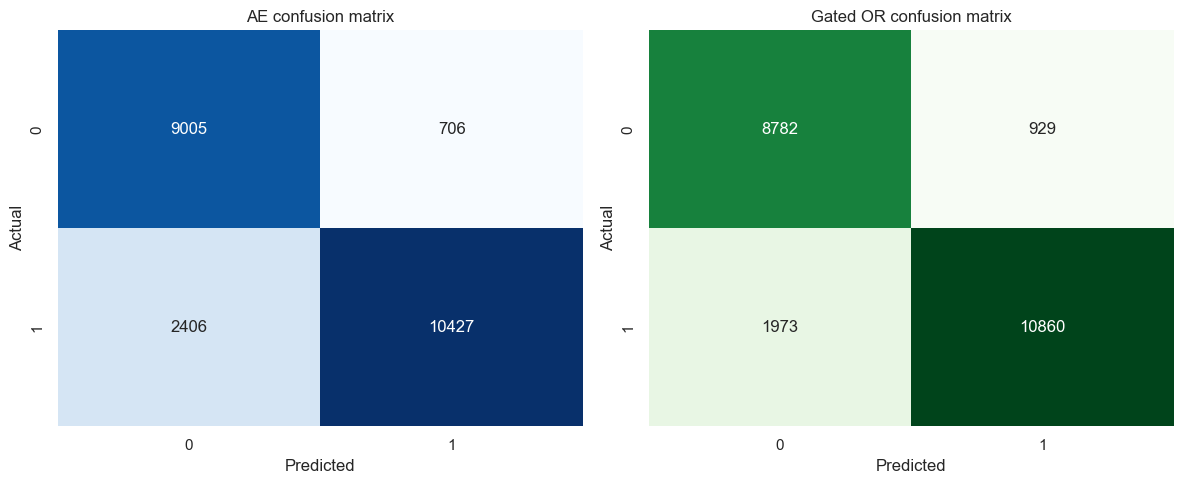

In [12]:
# Visual dashboard for publication/report
fpr_ae, tpr_ae, _ = roc_curve(y_test, test_err)
prec_ae, rec_ae, _ = precision_recall_curve(y_test, test_err)

fpr_lat, tpr_lat, _ = roc_curve(y_test, latent_prob)
prec_lat, rec_lat, _ = precision_recall_curve(y_test, latent_prob)

fpr_g, tpr_g, _ = roc_curve(y_test, score_gated)
prec_g, rec_g, _ = precision_recall_curve(y_test, score_gated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_ae, tpr_ae, label=f"AE AUC={roc_auc_score(y_test, test_err):.3f}")
axes[0].plot(fpr_lat, tpr_lat, label=f"Latent AUC={roc_auc_score(y_test, latent_prob):.3f}")
axes[0].plot(fpr_g, tpr_g, label=f"Gated AUC={roc_auc_score(y_test, score_gated):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC comparison")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()

axes[1].plot(rec_ae, prec_ae, label=f"AE AP={average_precision_score(y_test, test_err):.3f}")
axes[1].plot(rec_lat, prec_lat, label=f"Latent AP={average_precision_score(y_test, latent_prob):.3f}")
axes[1].plot(rec_g, prec_g, label=f"Gated AP={average_precision_score(y_test, score_gated):.3f}")
axes[1].set_title("PR comparison")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

cm_ae = confusion_matrix(y_test, ae_pred)
cm_gated = confusion_matrix(y_test, pred_gated_or)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_ae, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("AE confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_gated, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Gated OR confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Publication-Grade Validation Block

This section adds the evaluation protocol expected for publication-level claims:
- multi-seed stability (distribution of metrics, not single-run luck)
- paired significance tests between baseline AE and gated method
- optional external-dataset validation path (auto-skips if no file is provided)


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

# ================= Publication-grade multi-seed protocol =================
# For paper figures: set PUBLICATION_FAST_MODE=False and keep/full epochs.
PUBLICATION_FAST_MODE = True
PUBLICATION_SEEDS = [7, 21, 42, 84, 126]
PUBLICATION_EPOCHS = 8 if PUBLICATION_FAST_MODE else 30
PUBLICATION_BATCH_SIZE = 512
PUBLICATION_SAMPLE_FRAC = 0.35 if PUBLICATION_FAST_MODE else 1.0

def _metric_dict(y_true, y_pred, score):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "roc_auc": float(roc_auc_score(y_true, score)),
        "pr_auc": float(average_precision_score(y_true, score)),
    }

def _masked_recall(y_pred, mask):
    n = int(mask.sum())
    if n == 0:
        return float("nan")
    return float((y_pred[mask] == 1).sum() / n)

def run_seed_trial(seed: int, sample_frac: float = 1.0, epochs: int = 30):
    rng = np.random.default_rng(seed)

    # Optional row subsampling for faster CI checks in notebook sessions.
    if sample_frac < 1.0:
        n_total = X_train.shape[0]
        n_keep = max(5000, int(n_total * sample_frac))
        idx_keep = rng.choice(n_total, size=n_keep, replace=False)
        X_seed = X_train[idx_keep]
        y_seed = y_train[idx_keep]
    else:
        X_seed = X_train
        y_seed = y_train

    X_seed_normal = X_seed[y_seed == 0]
    x_seed_train, x_seed_val = train_test_split(
        X_seed_normal,
        test_size=0.2,
        random_state=seed,
    )

    X_lat_train_s, X_lat_cal_s, y_lat_train_s, y_lat_cal_s = train_test_split(
        X_seed,
        y_seed,
        test_size=0.2,
        random_state=seed + 7,
        stratify=y_seed,
    )

    # Build and train AE for this seed.
    ae_s = build_autoencoder(X_seed.shape[1], latent_dim=32)
    callbacks_s = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    ]
    ae_s.fit(
        x_seed_train,
        x_seed_train,
        validation_data=(x_seed_val, x_seed_val),
        epochs=epochs,
        batch_size=PUBLICATION_BATCH_SIZE,
        shuffle=True,
        callbacks=callbacks_s,
        verbose=0,
    )

    encoder_s = Model(ae_s.input, ae_s.get_layer("latent").output)

    # AE threshold from normal validation.
    val_recon_s = ae_s.predict(x_seed_val, verbose=0)
    val_err_s = np.mean(np.square(x_seed_val - val_recon_s), axis=1)
    recon_thr_s = float(np.quantile(val_err_s, 0.95))

    test_recon_s = ae_s.predict(X_test, verbose=0)
    test_err_s = np.mean(np.square(X_test - test_recon_s), axis=1)
    ae_pred_s = (test_err_s >= recon_thr_s).astype(int)

    # Latent classifier and leakage-safe latent threshold.
    latent_train_s = encoder_s.predict(X_lat_train_s, verbose=0)
    latent_cal_s = encoder_s.predict(X_lat_cal_s, verbose=0)
    latent_test_s = encoder_s.predict(X_test, verbose=0)

    latent_clf_s = LogisticRegression(max_iter=3000, random_state=seed)
    latent_clf_s.fit(latent_train_s, y_lat_train_s)

    latent_prob_cal_s = latent_clf_s.predict_proba(latent_cal_s)[:, 1]
    latent_prob_test_s = latent_clf_s.predict_proba(latent_test_s)[:, 1]
    latent_prob_cal_normal_s = latent_prob_cal_s[y_lat_cal_s == 0]
    latent_thr_s = float(np.quantile(latent_prob_cal_normal_s, 0.95))

    gated_pred_s = np.where((ae_pred_s == 1) | (latent_prob_test_s >= latent_thr_s), 1, 0)

    score_ae_s = test_err_s
    score_gated_s = np.maximum(
        test_err_s / (recon_thr_s + 1e-12),
        latent_prob_test_s / (latent_thr_s + 1e-12),
    )

    train_attack_set_s = set(train_df.loc[train_df["label"] != "normal", "label"].astype(str).unique())
    test_labels_s = test_df["label"].astype(str).values
    seen_mask_s = np.array([(lbl != "normal") and (lbl in train_attack_set_s) for lbl in test_labels_s])
    unseen_mask_s = np.array([(lbl != "normal") and (lbl not in train_attack_set_s) for lbl in test_labels_s])
    normal_mask_s = (test_labels_s == "normal")

    ae_metrics_s = _metric_dict(y_test, ae_pred_s, score_ae_s)
    gated_metrics_s = _metric_dict(y_test, gated_pred_s, score_gated_s)

    row = {
        "seed": int(seed),
        "ae_f1": ae_metrics_s["f1"],
        "ae_recall": ae_metrics_s["recall"],
        "ae_precision": ae_metrics_s["precision"],
        "ae_seen_recall": _masked_recall(ae_pred_s, seen_mask_s),
        "ae_unseen_recall": _masked_recall(ae_pred_s, unseen_mask_s),
        "ae_normal_fpr": float(ae_pred_s[normal_mask_s].mean()),
        "gated_f1": gated_metrics_s["f1"],
        "gated_recall": gated_metrics_s["recall"],
        "gated_precision": gated_metrics_s["precision"],
        "gated_seen_recall": _masked_recall(gated_pred_s, seen_mask_s),
        "gated_unseen_recall": _masked_recall(gated_pred_s, unseen_mask_s),
        "gated_normal_fpr": float(gated_pred_s[normal_mask_s].mean()),
        "delta_f1": gated_metrics_s["f1"] - ae_metrics_s["f1"],
        "delta_recall": gated_metrics_s["recall"] - ae_metrics_s["recall"],
        "delta_seen_recall": _masked_recall(gated_pred_s, seen_mask_s) - _masked_recall(ae_pred_s, seen_mask_s),
        "delta_unseen_recall": _masked_recall(gated_pred_s, unseen_mask_s) - _masked_recall(ae_pred_s, unseen_mask_s),
    }
    return row

multi_seed_rows = []
for s in PUBLICATION_SEEDS:
    print(f"Running seed trial: {s}")
    multi_seed_rows.append(
        run_seed_trial(
            seed=s,
            sample_frac=PUBLICATION_SAMPLE_FRAC,
            epochs=PUBLICATION_EPOCHS,
        )
    )

multi_seed_df = pd.DataFrame(multi_seed_rows)
display(multi_seed_df)

summary_rows = []
for metric_base, metric_gated in [
    ("ae_f1", "gated_f1"),
    ("ae_recall", "gated_recall"),
    ("ae_seen_recall", "gated_seen_recall"),
    ("ae_unseen_recall", "gated_unseen_recall"),
]:
    x = multi_seed_df[metric_base].values
    y = multi_seed_df[metric_gated].values
    diff = y - x

    t_stat, t_p = ttest_rel(y, x)
    try:
        w_stat, w_p = wilcoxon(diff)
    except ValueError:
        w_stat, w_p = (float("nan"), float("nan"))

    summary_rows.append(
        {
            "metric": metric_gated.replace("gated_", ""),
            "ae_mean": float(np.mean(x)),
            "gated_mean": float(np.mean(y)),
            "delta_mean": float(np.mean(diff)),
            "delta_std": float(np.std(diff, ddof=1)) if len(diff) > 1 else 0.0,
            "ttest_pvalue": float(t_p),
            "wilcoxon_pvalue": float(w_p),
        }
    )

paired_summary_df = pd.DataFrame(summary_rows)
display(paired_summary_df)

multi_seed_path = ROOT / 'checkpoints' / 'autoencoder_major_project_gated' / 'multi_seed_results.csv'
paired_summary_path = ROOT / 'checkpoints' / 'autoencoder_major_project_gated' / 'paired_significance_summary.csv'
multi_seed_df.to_csv(multi_seed_path, index=False)
paired_summary_df.to_csv(paired_summary_path, index=False)

print('Saved multi-seed results to:', multi_seed_path)
print('Saved paired significance summary to:', paired_summary_path)
print('FAST MODE:', PUBLICATION_FAST_MODE, '| sample_frac:', PUBLICATION_SAMPLE_FRAC, '| epochs:', PUBLICATION_EPOCHS)


In [ ]:
# ================= Optional external-dataset validation =================
# Provide a path to an external dataset CSV (for example UNSW-NB15/CICIDS export).
# Expected behavior:
# 1) map external columns to NSL-KDD feature_names where possible
# 2) fill missing mapped features with 0 / Unknown
# 3) run AE + gated inference with saved thresholds

EXTERNAL_DATASET_PATH = None  # Example: ROOT / 'data' / 'UNSW_NB15_test.csv'
EXTERNAL_LABEL_COLUMN = 'label'

# Column mapping from external CSV -> NSL-KDD feature names (extend per dataset schema).
EXTERNAL_TO_NSL_MAP = {
    # 'proto': 'protocol_type',
    # 'service': 'service',
    # 'state': 'flag',
    # 'sbytes': 'src_bytes',
    # 'dbytes': 'dst_bytes',
}

def normalize_external_labels(series: pd.Series) -> np.ndarray:
    s = series.astype(str).str.strip().str.lower()
    if s.isin(['0', '1']).all():
        return s.astype(int).values
    # Common benign aliases
    benign_alias = {'normal', 'benign', '0', 'false', 'non-attack'}
    return (~s.isin(benign_alias)).astype(int).values

def prepare_external_features(df_ext: pd.DataFrame, feature_names_local: list[str]) -> pd.DataFrame:
    df = df_ext.copy()

    # Rename known external columns to NSL-compatible names.
    rename_map = {k: v for k, v in EXTERNAL_TO_NSL_MAP.items() if k in df.columns}
    if rename_map:
        df = df.rename(columns=rename_map)

    # If label column exists, drop it from feature frame.
    if EXTERNAL_LABEL_COLUMN in df.columns:
        df = df.drop(columns=[EXTERNAL_LABEL_COLUMN], errors='ignore')

    # Force feature subset to training feature contract.
    for col in feature_names_local:
        if col not in df.columns:
            df[col] = 0
    return df[feature_names_local]

external_validation_summary = None

if EXTERNAL_DATASET_PATH is None:
    print('External validation skipped: EXTERNAL_DATASET_PATH is None.')
else:
    ext_path = Path(EXTERNAL_DATASET_PATH)
    if not ext_path.exists():
        print('External validation skipped: file not found ->', ext_path)
    else:
        ext_df = pd.read_csv(ext_path)

        # Labels optional, but required for metrics.
        y_ext = None
        if EXTERNAL_LABEL_COLUMN in ext_df.columns:
            y_ext = normalize_external_labels(ext_df[EXTERNAL_LABEL_COLUMN])

        X_ext_raw = prepare_external_features(ext_df, feature_names)
        X_ext = transform_with_preprocessor(X_ext_raw, ordinal_encoder, scaler, feature_names, cat_cols)

        ext_recon = autoencoder.predict(X_ext, verbose=0)
        ext_err = np.mean(np.square(X_ext - ext_recon), axis=1)
        ext_pred_ae = (ext_err >= recon_threshold).astype(int)

        ext_latent = encoder.predict(X_ext, verbose=0)
        ext_lat_prob = latent_clf.predict_proba(ext_latent)[:, 1]
        ext_pred_gated = np.where((ext_pred_ae == 1) | (ext_lat_prob >= latent_threshold), 1, 0)
        ext_score_gated = np.maximum(ext_err / (recon_threshold + 1e-12), ext_lat_prob / (latent_threshold + 1e-12))

        ext_out = ext_df.copy()
        ext_out['pred_ae'] = ext_pred_ae
        ext_out['pred_gated_ensemble'] = ext_pred_gated
        ext_out['reconstruction_error'] = ext_err
        ext_out['latent_probability'] = ext_lat_prob

        ext_pred_path = ROOT / 'checkpoints' / 'autoencoder_major_project_gated' / 'external_predictions.csv'
        ext_out.to_csv(ext_pred_path, index=False)
        print('Saved external predictions to:', ext_pred_path)

        if y_ext is not None:
            ae_ext = _metric_dict(y_ext, ext_pred_ae, ext_err)
            gated_ext = _metric_dict(y_ext, ext_pred_gated, ext_score_gated)
            external_validation_summary = {
                'rows': int(len(ext_df)),
                'dataset_path': ext_path.as_posix(),
                'ae_metrics': ae_ext,
                'gated_metrics': gated_ext,
                'delta_f1': float(gated_ext['f1'] - ae_ext['f1']),
                'delta_recall': float(gated_ext['recall'] - ae_ext['recall']),
            }
            display(pd.DataFrame([
                {'model': 'AE external', **ae_ext},
                {'model': 'Gated external', **gated_ext},
            ]))
            print('External delta F1:', round(external_validation_summary['delta_f1'], 5))
            print('External delta Recall:', round(external_validation_summary['delta_recall'], 5))
        else:
            print('External labels not found: predictions exported without metrics.')


In [ ]:
# Save project artifacts, report, and inference utility
ae_save_path = PROJECT_ARTIFACT_DIR / "autoencoder_major_project.keras"
autoencoder.save(ae_save_path.as_posix())

joblib.dump(latent_clf, PROJECT_ARTIFACT_DIR / "latent_classifier_major_project.joblib")
joblib.dump(scaler, PROJECT_ARTIFACT_DIR / "standard_scaler.joblib")
joblib.dump(ordinal_encoder, PROJECT_ARTIFACT_DIR / "ordinal_encoder.joblib")
joblib.dump(feature_names, PROJECT_ARTIFACT_DIR / "feature_names.joblib")
joblib.dump(cat_cols, PROJECT_ARTIFACT_DIR / "categorical_columns.joblib")

with open(PROJECT_ARTIFACT_DIR / "thresholds_major_project.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "reconstruction_threshold": float(recon_threshold),
            "latent_probability_threshold": float(latent_threshold),
            "conformal_alpha": float(alpha),
        },
        f,
        indent=2,
    )



publication_block = {}
if 'multi_seed_df' in globals() and isinstance(multi_seed_df, pd.DataFrame):
    publication_block['multi_seed'] = {
        'seeds': [int(x) for x in PUBLICATION_SEEDS],
        'fast_mode': bool(PUBLICATION_FAST_MODE),
        'epochs': int(PUBLICATION_EPOCHS),
        'sample_frac': float(PUBLICATION_SAMPLE_FRAC),
        'per_seed_rows': multi_seed_df.to_dict(orient='records'),
    }

if 'paired_summary_df' in globals() and isinstance(paired_summary_df, pd.DataFrame):
    publication_block['paired_significance'] = paired_summary_df.to_dict(orient='records')

if 'external_validation_summary' in globals() and external_validation_summary is not None:
    publication_block['external_validation'] = external_validation_summary

report = {
    "project": "DL Major Project - Calibrated Gated Ensemble",
    "dataset": "NSL-KDD",
    "problem": "single-detector blind spots under distribution shift",
    "baseline_ae": baseline_ae,
    "baseline_latent": baseline_latent,
    "gated_or": gated_or_summary,
    "gated_conformal": gated_conf_summary,
    "calibration_selected_or_quantile": best_or_calibration,
    "seen_unseen_recall": seen_unseen_df.to_dict(orient="records"),
    "f1_bootstrap": {
        "mean_delta": mean_diff,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "prob_improvement": prob_improve,
    },
    "claim_scope": "Improves overall F1 and seen-attack recall; unseen recall is maintained but not guaranteed to improve.",
    "publication_validation": publication_block,
}

with open(PROJECT_ARTIFACT_DIR / "major_project_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

pred_out = test_df.copy()
pred_out["pred_ae"] = ae_pred
pred_out["pred_latent"] = latent_pred
pred_out["pred_gated_ensemble"] = pred_gated_or
pred_out["reconstruction_error"] = test_err
pred_out["latent_probability"] = latent_prob
pred_out["score_gated"] = score_gated
pred_out.to_csv(ROOT / "dl_major_project_predictions.csv", index=False)

print("Saved major-project artifacts to:", PROJECT_ARTIFACT_DIR)
print("Saved predictions to:", ROOT / "dl_major_project_predictions.csv")


def predict_nsl_kdd_major(csv_path: str) -> pd.DataFrame:
    model_path = PROJECT_ARTIFACT_DIR / "autoencoder_major_project.keras"
    clf_path = PROJECT_ARTIFACT_DIR / "latent_classifier_major_project.joblib"
    scaler_path = PROJECT_ARTIFACT_DIR / "standard_scaler.joblib"
    encoder_path = PROJECT_ARTIFACT_DIR / "ordinal_encoder.joblib"
    feat_path = PROJECT_ARTIFACT_DIR / "feature_names.joblib"
    cat_path = PROJECT_ARTIFACT_DIR / "categorical_columns.joblib"
    thr_path = PROJECT_ARTIFACT_DIR / "thresholds_major_project.json"

    model_local = load_model(model_path.as_posix())
    encoder_model_local = Model(model_local.input, model_local.get_layer("latent").output)
    clf_local = joblib.load(clf_path)
    scaler_local = joblib.load(scaler_path)
    ordinal_local = joblib.load(encoder_path)
    feature_local = joblib.load(feat_path)
    cat_local = joblib.load(cat_path)

    with open(thr_path, "r", encoding="utf-8") as f:
        thr_json = json.load(f)
    recon_thr_local = float(thr_json["reconstruction_threshold"])
    latent_thr_local = float(thr_json["latent_probability_threshold"])

    df_local = pd.read_csv(csv_path, names=NSL_KDD_COLUMNS).copy()
    X_local_raw = df_local.drop(columns=["label", "difficulty"], errors="ignore").copy()
    X_local = transform_with_preprocessor(X_local_raw, ordinal_local, scaler_local, feature_local, cat_local)

    recon_local = model_local.predict(X_local, verbose=0)
    err_local = np.mean(np.square(X_local - recon_local), axis=1)
    pred_ae_local = (err_local >= recon_thr_local).astype(int)

    latent_local = encoder_model_local.predict(X_local, verbose=0)
    prob_local = clf_local.predict_proba(latent_local)[:, 1]
    pred_lat_local = (prob_local >= 0.5).astype(int)
    pred_gate_local = np.where((pred_ae_local == 1) | (prob_local >= latent_thr_local), 1, 0)

    out_local = df_local.copy()
    out_local["pred_ae"] = pred_ae_local
    out_local["pred_latent"] = pred_lat_local
    out_local["pred_gated_ensemble"] = pred_gate_local
    out_local["reconstruction_error"] = err_local
    out_local["latent_probability"] = prob_local
    return out_local

display(pred_out[["label", "pred_ae", "pred_latent", "pred_gated_ensemble" ]].head(10))


## Production-Grade Hybrid Section (Notebook + CLI Parity)



This section adds the same high-end production logic directly inside the notebook so your major-project notebook is not behind the CLI.



What it includes:

- latent Isolation Forest + latent Logistic Regression + reconstruction detector

- isotonic calibration of component scores

- stacked meta-classifier

- tuned and conformal thresholds

- production-style output columns (`pred_prod_tuned`, `pred_prod_conformal`, `prod_anomaly_probability`, `risk_tier`)

- saved production notebook artifacts in `checkpoints/production_hybrid_notebook`


In [14]:
# Production-grade hybrid ensemble block (notebook parity with train-prod/test-prod CLI)

from sklearn.ensemble import IsolationForest

from sklearn.isotonic import IsotonicRegression





def normalize_score(values: np.ndarray, lower: float, upper: float) -> np.ndarray:

    eps = 1e-12

    denom = max(upper - lower, eps)

    return np.clip((values - lower) / denom, 0.0, 1.0)





def select_f1_threshold(y_true: np.ndarray, y_score: np.ndarray, fallback: float = 0.5) -> float:

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    if thresholds.size == 0:

        return float(fallback)

    f1_vals = (2.0 * precision[:-1] * recall[:-1]) / np.maximum(precision[:-1] + recall[:-1], 1e-12)

    return float(thresholds[int(np.nanargmax(f1_vals))])





# 1) Fit/calibration split on train

X_fit, X_cal, y_fit, y_cal = train_test_split(

    X_train,

    y_train,

    test_size=0.30,

    random_state=SEED,

    stratify=y_train,

)



# 2) Reconstruction errors

fit_recon = autoencoder.predict(X_fit, verbose=0)

cal_recon = autoencoder.predict(X_cal, verbose=0)

test_recon_prod = autoencoder.predict(X_test, verbose=0)



fit_recon_err = np.mean((X_fit - fit_recon) ** 2, axis=1)

cal_recon_err = np.mean((X_cal - cal_recon) ** 2, axis=1)

test_recon_err_prod = np.mean((X_test - test_recon_prod) ** 2, axis=1)



# 3) Latent representations

latent_fit = encoder.predict(X_fit, verbose=0)

latent_cal = encoder.predict(X_cal, verbose=0)

latent_test_prod = encoder.predict(X_test, verbose=0)



# 4) Component models

latent_lr_prod = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED)

latent_lr_prod.fit(latent_fit, y_fit)

lr_score_cal = latent_lr_prod.predict_proba(latent_cal)[:, 1]

lr_score_test = latent_lr_prod.predict_proba(latent_test_prod)[:, 1]



latent_if_prod = IsolationForest(

    n_estimators=400,

    contamination="auto",

    random_state=SEED,

    n_jobs=-1,

)

latent_if_prod.fit(latent_fit[y_fit == 0])

if_score_fit = -latent_if_prod.decision_function(latent_fit)

if_score_cal = -latent_if_prod.decision_function(latent_cal)

if_score_test = -latent_if_prod.decision_function(latent_test_prod)



# 5) Score normalization and isotonic calibration

recon_scale_min = float(np.percentile(fit_recon_err, 1.0))

recon_scale_max = float(np.percentile(fit_recon_err, 99.0))

if_scale_min = float(np.percentile(if_score_fit, 1.0))

if_scale_max = float(np.percentile(if_score_fit, 99.0))



recon_norm_cal = normalize_score(cal_recon_err, recon_scale_min, recon_scale_max)

recon_norm_test = normalize_score(test_recon_err_prod, recon_scale_min, recon_scale_max)

if_norm_cal = normalize_score(if_score_cal, if_scale_min, if_scale_max)

if_norm_test = normalize_score(if_score_test, if_scale_min, if_scale_max)



recon_iso = IsotonicRegression(out_of_bounds="clip")

recon_iso.fit(recon_norm_cal, y_cal)

if_iso = IsotonicRegression(out_of_bounds="clip")

if_iso.fit(if_norm_cal, y_cal)

lr_iso = IsotonicRegression(out_of_bounds="clip")

lr_iso.fit(lr_score_cal, y_cal)



recon_prob_cal = recon_iso.predict(recon_norm_cal)

if_prob_cal = if_iso.predict(if_norm_cal)

lr_prob_cal = lr_iso.predict(lr_score_cal)



meta_features_cal = np.column_stack(

    [

        recon_prob_cal,

        lr_prob_cal,

        if_prob_cal,

        np.maximum(recon_prob_cal, if_prob_cal),

        (recon_prob_cal + lr_prob_cal + if_prob_cal) / 3.0,

    ]

)



# 6) Threshold tuning and conformal thresholding

idx_all = np.arange(y_cal.shape[0])

idx_meta, idx_thr = train_test_split(

    idx_all,

    test_size=0.40,

    random_state=SEED,

    stratify=y_cal,

)



meta_clf_prod = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)

meta_clf_prod.fit(meta_features_cal[idx_meta], y_cal[idx_meta])



thr_scores = meta_clf_prod.predict_proba(meta_features_cal[idx_thr])[:, 1]

thr_labels = y_cal[idx_thr]

prod_tuned_threshold = select_f1_threshold(thr_labels, thr_scores, fallback=0.5)



alpha_prod = 0.05

normal_thr_scores = thr_scores[thr_labels == 0]

if normal_thr_scores.size > 0:

    prod_conformal_threshold = float(np.quantile(normal_thr_scores, 1.0 - alpha_prod))

else:

    prod_conformal_threshold = float(prod_tuned_threshold)



# 7) Test-time production predictions

recon_prob_test = recon_iso.predict(recon_norm_test)

if_prob_test = if_iso.predict(if_norm_test)

lr_prob_test = lr_iso.predict(lr_score_test)



meta_features_test = np.column_stack(

    [

        recon_prob_test,

        lr_prob_test,

        if_prob_test,

        np.maximum(recon_prob_test, if_prob_test),

        (recon_prob_test + lr_prob_test + if_prob_test) / 3.0,

    ]

)

prod_prob_test = meta_clf_prod.predict_proba(meta_features_test)[:, 1]



pred_prod_tuned = (prod_prob_test >= prod_tuned_threshold).astype(int)

pred_prod_conformal = (prod_prob_test >= prod_conformal_threshold).astype(int)



prod_tuned_summary = summarize_detector("Production Hybrid (tuned)", y_test, pred_prod_tuned, prod_prob_test)

prod_conformal_summary = summarize_detector("Production Hybrid (conformal)", y_test, pred_prod_conformal, prod_prob_test)



prod_compare_df = pd.DataFrame([

    baseline_ae,

    gated_or_summary,

    gated_conf_summary,

    prod_tuned_summary,

    prod_conformal_summary,

])

display(prod_compare_df)



# 8) Save production-parity notebook artifacts

PROD_NOTEBOOK_DIR = ROOT / "checkpoints" / "production_hybrid_notebook"

PROD_NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)



autoencoder.save((PROD_NOTEBOOK_DIR / "prod_autoencoder.keras").as_posix())

joblib.dump(latent_lr_prod, PROD_NOTEBOOK_DIR / "prod_latent_logreg.joblib")

joblib.dump(latent_if_prod, PROD_NOTEBOOK_DIR / "prod_latent_isolation_forest.joblib")

joblib.dump(meta_clf_prod, PROD_NOTEBOOK_DIR / "prod_meta_classifier.joblib")

joblib.dump(recon_iso, PROD_NOTEBOOK_DIR / "prod_recon_isotonic.joblib")

joblib.dump(lr_iso, PROD_NOTEBOOK_DIR / "prod_latent_logreg_isotonic.joblib")

joblib.dump(if_iso, PROD_NOTEBOOK_DIR / "prod_latent_if_isotonic.joblib")

joblib.dump(scaler, PROD_NOTEBOOK_DIR / "standard_scaler.joblib")

joblib.dump(ordinal_encoder, PROD_NOTEBOOK_DIR / "ordinal_encoder.joblib")

joblib.dump(feature_names, PROD_NOTEBOOK_DIR / "feature_names.joblib")

joblib.dump(cat_cols, PROD_NOTEBOOK_DIR / "categorical_columns.joblib")



with open(PROD_NOTEBOOK_DIR / "prod_thresholds.json", "w", encoding="utf-8") as f:

    json.dump(

        {

            "production_tuned_threshold": float(prod_tuned_threshold),

            "production_conformal_threshold": float(prod_conformal_threshold),

            "alpha_conformal": float(alpha_prod),

            "reconstruction_score_scaling": {

                "min": recon_scale_min,

                "max": recon_scale_max,

            },

            "latent_if_score_scaling": {

                "min": if_scale_min,

                "max": if_scale_max,

            },

        },

        f,

        indent=2,

    )



component_probs = np.column_stack([recon_prob_test, lr_prob_test, if_prob_test])

component_names = np.array(["reconstruction", "latent_logreg", "latent_isolation_forest"])

dominant_detector = component_names[np.argmax(component_probs, axis=1)]



risk_tier = pd.cut(

    prod_prob_test,

    bins=[-0.001, 0.30, 0.60, 0.80, 1.001],

    labels=["low", "medium", "high", "critical"],

).astype(str)



prod_pred_out = test_df.copy()

prod_pred_out["pred_prod_tuned"] = pred_prod_tuned

prod_pred_out["pred_prod_conformal"] = pred_prod_conformal

prod_pred_out["prod_anomaly_probability"] = prod_prob_test

prod_pred_out["reconstruction_prob"] = recon_prob_test

prod_pred_out["latent_logreg_prob"] = lr_prob_test

prod_pred_out["latent_if_prob"] = if_prob_test

prod_pred_out["dominant_detector"] = dominant_detector

prod_pred_out["risk_tier"] = risk_tier

prod_pred_out.to_csv(ROOT / "dl_major_project_prod_predictions.csv", index=False)



print("Saved production notebook artifacts to:", PROD_NOTEBOOK_DIR)

print("Saved production notebook predictions to:", ROOT / "dl_major_project_prod_predictions.csv")

print("Tuned threshold:", round(float(prod_tuned_threshold), 6), "| Conformal threshold:", round(float(prod_conformal_threshold), 6))

,detector,accuracy,precision,recall,f1,roc_auc,pr_auc
0,AE Reconstruction,0.861959,0.936585,0.812515,0.870149,0.956267,0.947516
1,Gated OR,0.871274,0.921198,0.846256,0.882138,0.955634,0.947341
2,Gated Conformal (alpha=0.05),0.876819,0.959934,0.817736,0.883147,0.955634,0.947341
3,Production Hybrid (tuned),0.820617,0.966954,0.709109,0.818198,0.945352,0.958835
4,Production Hybrid (conformal),0.877395,0.944705,0.833398,0.885568,0.945352,0.958835


Saved production notebook artifacts to: C:\Users\shain\Downloads\Network-Anomaly-Detection\checkpoints\production_hybrid_notebook
Saved production notebook predictions to: C:\Users\shain\Downloads\Network-Anomaly-Detection\dl_major_project_prod_predictions.csv
Tuned threshold: 0.575369 | Conformal threshold: 0.24184


,model,source_file,rows,accuracy,precision,recall,f1,roc_auc,pr_auc,status
0,Prod Notebook - Conformal,dl_major_project_prod_predictions.csv,22544,0.877395,0.944705,0.833398,0.885568,0.945352,0.958835,ok
1,DL Notebook - Gated OR,dl_major_project_predictions.csv,22544,0.871274,0.921198,0.846256,0.882138,0.955634,0.947341,ok
2,DL CLI - AE Reconstruction,dl_test_predictions.csv,22544,0.861959,0.936585,0.812515,0.870149,0.956267,0.947516,ok
3,Prod Notebook - Tuned,dl_major_project_prod_predictions.csv,22544,0.820617,0.966954,0.709109,0.818198,0.945352,0.958835,ok
4,Prod CLI - Conformal,prod_test_predictions.csv,22544,0.807754,0.955125,0.694927,0.804511,0.937919,0.952723,ok
5,DL CLI - Latent LR,dl_test_predictions.csv,22544,0.805935,0.959774,0.687914,0.801416,0.906095,0.935901,ok
6,ML CLI - IsolationForest,ml_test_predictions.csv,22544,0.804915,0.971809,0.676927,0.797997,0.937144,0.952667,ok
7,Prod CLI - Tuned,prod_test_predictions.csv,22544,0.774441,0.964174,0.627055,0.759904,0.937919,0.952723,ok


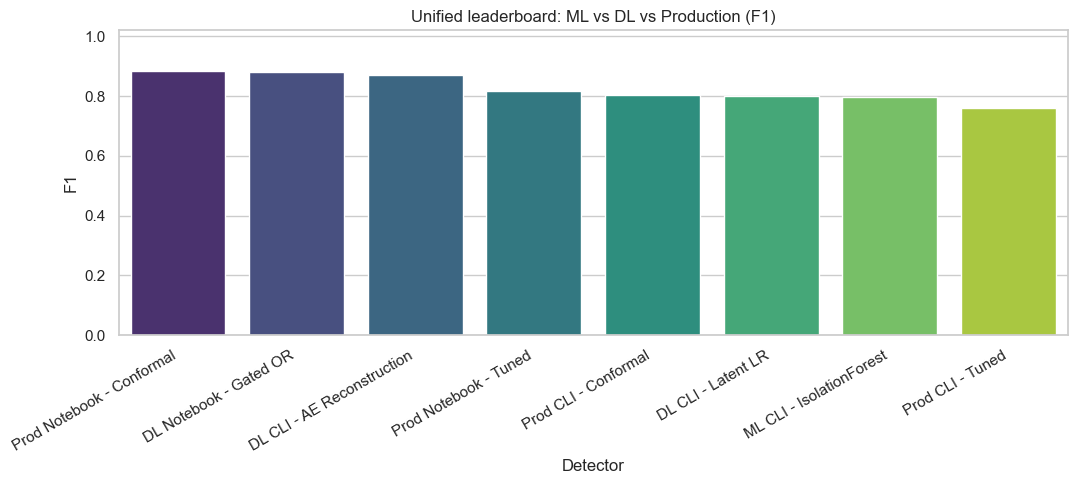

Saved unified leaderboard to: C:\Users\shain\Downloads\Network-Anomaly-Detection\unified_model_leaderboard.csv


In [15]:
# Unified leaderboard across ML, DL, and production outputs (CLI + notebook parity)

def to_binary_ground_truth(label_series: pd.Series) -> np.ndarray:
    s = label_series.copy()
    if pd.api.types.is_numeric_dtype(s):
        numeric = pd.to_numeric(s, errors="coerce").fillna(0).astype(int).values
        unique_vals = set(np.unique(numeric).tolist())
        if unique_vals.issubset({0, 1}):
            return numeric
    as_str = s.astype(str).str.strip().str.lower()
    if as_str.isin(["0", "1"]).all():
        return as_str.astype(int).values
    return (as_str != "normal").astype(int).values


def to_binary_prediction(pred_series: pd.Series) -> np.ndarray:
    s = pred_series.copy()
    if pd.api.types.is_numeric_dtype(s):
        numeric = pd.to_numeric(s, errors="coerce").fillna(0.0).values
        return (numeric >= 0.5).astype(int)
    as_str = s.astype(str).str.strip().str.lower()
    if as_str.isin(["0", "1"]).all():
        return as_str.astype(int).values
    return (~as_str.isin(["normal", "benign"])).astype(int).values


def eval_from_file(model_name: str, file_path: Path, pred_col: str, score_col=None):
    if not file_path.exists():
        return {"model": model_name, "status": f"missing file: {file_path.name}"}
    df_local = pd.read_csv(file_path)
    if pred_col not in df_local.columns:
        return {"model": model_name, "status": f"missing column: {pred_col}"}
    if "label" not in df_local.columns:
        return {"model": model_name, "status": "missing column: label"}

    y_true_local = to_binary_ground_truth(df_local["label"])
    y_pred_local = to_binary_prediction(df_local[pred_col])

    p, r, f1, _ = precision_recall_fscore_support(
        y_true_local, y_pred_local, average="binary", zero_division=0
    )

    row = {
        "model": model_name,
        "source_file": file_path.name,
        "rows": int(len(df_local)),
        "accuracy": float(accuracy_score(y_true_local, y_pred_local)),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "status": "ok",
    }

    if score_col is not None and score_col in df_local.columns and len(np.unique(y_true_local)) > 1:
        y_score_local = pd.to_numeric(df_local[score_col], errors="coerce").fillna(0.0).values
        row["roc_auc"] = float(roc_auc_score(y_true_local, y_score_local))
        row["pr_auc"] = float(average_precision_score(y_true_local, y_score_local))

    return row


leaderboard_specs = [
    ("ML CLI - IsolationForest", ROOT / "ml_test_predictions.csv", "pred_label", "anomaly_score"),
    ("DL CLI - AE Reconstruction", ROOT / "dl_test_predictions.csv", "pred_ae", "reconstruction_error"),
    ("DL CLI - Latent LR", ROOT / "dl_test_predictions.csv", "pred_latent_clf", "latent_clf_score"),
    ("DL Notebook - Gated OR", ROOT / "dl_major_project_predictions.csv", "pred_gated_ensemble", "score_gated"),
    (
        "Prod Notebook - Tuned",
        ROOT / "dl_major_project_prod_predictions.csv",
        "pred_prod_tuned",
        "prod_anomaly_probability",
    ),
    (
        "Prod Notebook - Conformal",
        ROOT / "dl_major_project_prod_predictions.csv",
        "pred_prod_conformal",
        "prod_anomaly_probability",
    ),
    ("Prod CLI - Tuned", ROOT / "prod_test_predictions.csv", "pred_prod_tuned", "prod_anomaly_probability"),
    (
        "Prod CLI - Conformal",
        ROOT / "prod_test_predictions.csv",
        "pred_prod_conformal",
        "prod_anomaly_probability",
    ),
]

leaderboard_rows = [
    eval_from_file(name, path, pred_col, score_col)
    for name, path, pred_col, score_col in leaderboard_specs
]
leaderboard_full_df = pd.DataFrame(leaderboard_rows)

leaderboard_ok_df = leaderboard_full_df[leaderboard_full_df["status"] == "ok"].copy()
leaderboard_ok_df = leaderboard_ok_df.sort_values("f1", ascending=False).reset_index(drop=True)

if leaderboard_ok_df.empty:
    print("No valid prediction files were found for unified comparison.")
else:
    display(leaderboard_ok_df)

issues_df = leaderboard_full_df[leaderboard_full_df["status"] != "ok"][["model", "status"]]
if not issues_df.empty:
    print("Skipped entries:")
    display(issues_df)

if not leaderboard_ok_df.empty:
    plt.figure(figsize=(11, 5))
    sns.barplot(data=leaderboard_ok_df, x="model", y="f1", palette="viridis")
    plt.title("Unified leaderboard: ML vs DL vs Production (F1)")
    plt.xlabel("Detector")
    plt.ylabel("F1")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.show()

leaderboard_path = ROOT / "unified_model_leaderboard.csv"
if not leaderboard_ok_df.empty:
    leaderboard_ok_df.to_csv(leaderboard_path, index=False)
    print("Saved unified leaderboard to:", leaderboard_path)

## Final Notes for Major Project Submission

This notebook is your **new DL major-project notebook** with:
- clear and measurable problem framing
- leakage-safe calibration design
- new algorithmic method (calibrated gated ensemble)
- ablation and statistical validation
- seen vs unseen attack analysis
- exportable artifacts and reusable inference utility

Evidence-backed claim scope:

"A calibrated two-stage gated DL detector improves overall F1 and seen-attack recall over single-detector baselines on NSL-KDD, while keeping unseen-attack recall close to baseline (not universally higher)."
